In [1]:
import sys
from pathlib import Path

# add parent directory to Python path
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.linalg import norm
import pandas as pd

In [2]:
from dgp import generate_gaussian_data
from methods import solve_independent, aggregate_results, solve_dependent
from metrics import rv_coefficient, mse
from plot_functions import plot_grid, plot_with_bands

In [3]:
def objective_function(n, k, M, A, B, sigma):
    M_zz = M[:n, :n]
    M_xx = M[n:,n:]
    M_xz = M[:n, n:]
    M_zx = M[n:, :n]
    
    first = n*k*np.log(1-sigma**2)
    second = norm(M_zz-A, ord='fro') + norm(M_xx-B, ord='fro')
    
    factor = 1/(1-sigma**2)
    third = np.trace(M_xx) + np.trace(M_zz) - sigma*np.trace(M_xz) - sigma*np.trace(M_zx)
    
    out = first + second + factor * third
    return out

In [4]:
rng = np.random.default_rng(4)
n = 200
k = 3
sigma = 0.5
edge_var = 1
A, B, Z, X = generate_gaussian_data(n=n, k=k, sigma=sigma, edge_var=edge_var, rng=rng)
M = np.block([[Z@Z.T, X@Z.T], [X@Z.T, Z@Z.T]])

Ms, sigmas = solve_dependent(A, B, k=k, niters=10, step_size=0.1)

errs_M = [mse(Ms[i], M) for i in range(len(Ms))]
errs_sigma = [np.abs(np.abs(sigmas[i])- np.abs(sigma)) for i in range(len(sigmas))]

obj_out = []
for i in range(len(Ms)):
    t = objective_function(n, k, Ms[i], A, B, sigmas[i])
    obj_out.append(t)

In [5]:
objective_function(n, k, M, A, B, sigma)

np.float64(1740.6752378355889)

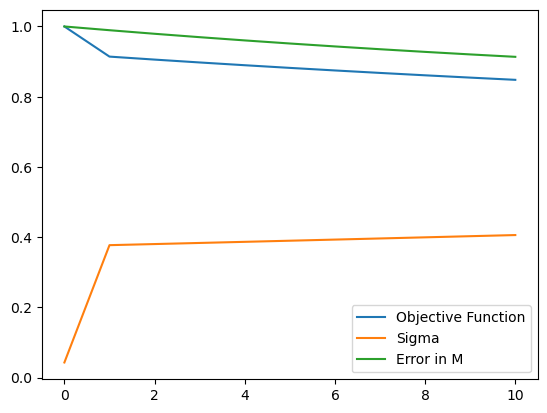

In [6]:
fig, ax = plt.subplots()
ax.plot(obj_out/max(obj_out), label='Objective Function')
ax.plot(np.abs(sigmas), label='Sigma')
ax.plot(np.array(errs_M)/max(errs_M), label='Error in M')
plt.legend()
plt.show()

In [ ]:
from methods import solver_grid

In [13]:
rng = np.random.default_rng(4)
n = 200
k = 3
sigma = 0.5
edge_var = 1
A, B, Z, X = generate_gaussian_data(n=n, k=k, sigma=sigma, edge_var=edge_var, rng=rng)
M = np.block([[Z@Z.T, X@Z.T], [X@Z.T, Z@Z.T]])

In [21]:
niter = 10
step_size = 1
grid = 0.1
out = solver_grid(A, B, k, niters=niter, step_size=step_size, grid=grid)

[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
[np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1), np.float64(0.1)]
[np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2), np.float64(0.2)]
[np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004), np.float64(0.30000000000000004)]
[np.float64(0.4), np.float64(0.4), np.float64(0.4), np.float64(0.4), np.

In [22]:
out

{np.float64(0.0): np.float64(1146.3881573092472),
 np.float64(0.1): np.float64(1164.630370517344),
 np.float64(0.2): np.float64(1183.955782885971),
 np.float64(0.30000000000000004): np.float64(1239.2758909220543),
 np.float64(0.4): np.float64(1156.3275156248749),
 np.float64(0.5): np.float64(1148.4185349595205),
 np.float64(0.6000000000000001): np.float64(1171.3368414308147),
 np.float64(0.7000000000000001): np.float64(1375.1862785690082),
 np.float64(0.8): np.float64(1034.7392132249847),
 np.float64(0.9): np.float64(772.783423519897)}

In [17]:
best_sigma = min(out, key=out.get)
best_sigma

np.float64(0.9)

In [11]:
Ms, sigmas = solve_dependent(A, B, k, niters, lambda_reg, step_size, 
                                         fit_sigma=False, sigma=sigma)

NameError: name 'niters' is not defined

In [ ]:
out

{np.float64(0.0): np.float64(1206.2533982812151)}

In [ ]:
def simulation(nsim, n, k, sigma, edge_var, dgp, metric, rng, solver, step_size):
    if not isinstance(dgp, list):
        dgp = [dgp]
    if not isinstance(sigma, list):
        sigma = [sigma]
    if not isinstance(edge_var, list):
        edge_var = [edge_var]
    if not isinstance(n, list):
        n = [n]
    if not isinstance(k, list):
        k = [k]
    if not isinstance(step_size, list):
        step_size = [step_size]

    factorial_design = list(itertools.product(n, k, sigma, edge_var, dgp, step_size))
    out = []

    for i in range(nsim):
        print(f"Simulation {i+1} of {nsim}")
        for scenario in factorial_design:
            n, k, sigma, edge_var, dgp, step_size = scenario
            A, B, Z, X = dgp(n, k, sigma, edge_var=edge_var, rng=rng)
            true_M = np.block([[Z@Z.T, X@Z.T], [X@Z.T, Z@Z.T]])
            estimated_M, estimated_sigma = solver(A, B, k=k, niters=5, step_size=step_size)
            estimated_M = estimated_M[-1]
            estimated_sigma = estimated_sigma[-1]

            err_M = metric(estimated_M, true_M)
            err_sigma = np.abs(estimated_sigma - sigma)
            out.append({'n': n, 'k': k, 'sigma': sigma, 'edge_var': edge_var, 'step_size': step_size, 'err_M': err_M, 'err_sigma': err_sigma})
    return pd.DataFrame(out)

In [ ]:
nsim = 10
n = [100, 200, 300, 400]
sigma = 0.5
edge_var = [0.1, 1, 2]
k = [1, 10]
step_size = [-1, 1, 1e1, 1e2]
rng = np.random.default_rng(1)

out = simulation(nsim=nsim, n=n, k=k, sigma=sigma, edge_var=edge_var, 
                 dgp=generate_gaussian_data, metric=mse, rng=rng, 
                 solver=solve_dependent, step_size=step_size)


Simulation 1 of 10
Simulation 2 of 10
Simulation 3 of 10
Simulation 4 of 10
Simulation 5 of 10
Simulation 6 of 10
Simulation 7 of 10
Simulation 8 of 10
Simulation 9 of 10
Simulation 10 of 10


In [ ]:
out_M = out.drop(columns=['err_sigma'])
out_sigma = out.drop(columns=['err_M'])

agg_out_M = aggregate_results(out_M, y_axis='err_M', x_axis='n', factors=['step_size', 'edge_var', 'k'])
agg_out_sigma = aggregate_results(out_sigma, y_axis='err_sigma', x_axis='n', factors=['step_size', 'edge_var', 'k'])

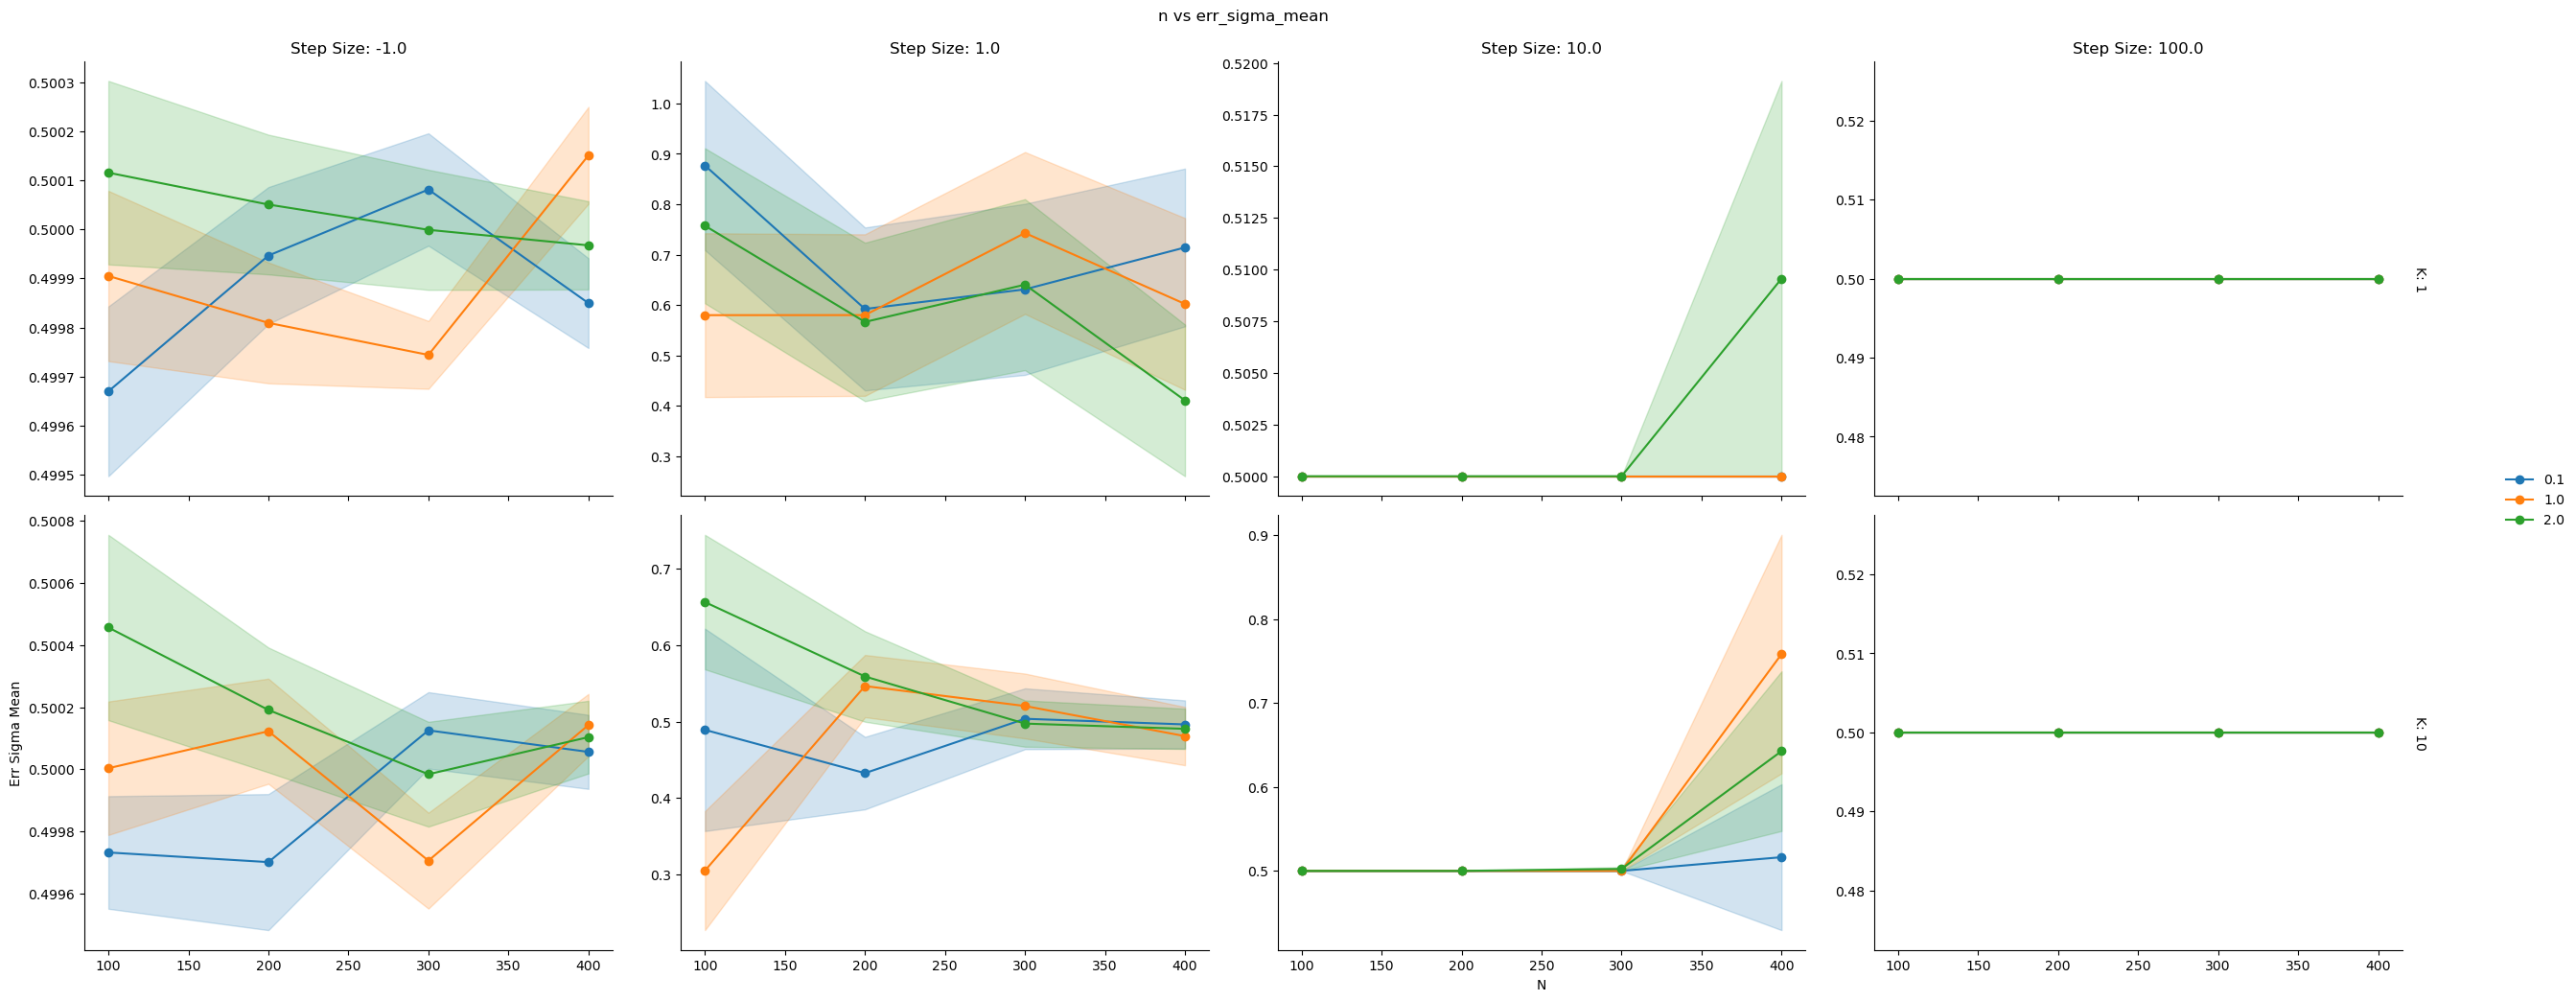

In [ ]:
out_M = out.drop(columns=['err_sigma'])
out_sigma = out.drop(columns=['err_M'])

agg_out_M = aggregate_results(out_M, y_axis='err_M', x_axis='n', factors=['step_size', 'edge_var', 'k'])
agg_out_sigma = aggregate_results(out_sigma, y_axis='err_sigma', x_axis='n', factors=['step_size', 'edge_var', 'k'])

plot_grid(
        grouped_stats=agg_out_sigma,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='err_sigma_mean',
        factors=['edge_var', 'step_size', 'k'],
        height=5,
        se_bands='err_sigma_sem',
        share_x=True,
        share_y=False
    )

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
out.groupby('n').mean()[['err_M', 'err_sigma']]

,err_M,err_sigma
n,,
100,249.891910,0.527706
200,250.274400,0.511538
300,248.134223,0.522429
400,248.021194,0.525935


#### Independence test

In [ ]:
rng = np.random.default_rng(1)
n = 50
k = 5
edge_var = 5
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)
rv_est = rv_coefficient(Zhat, Xhat)
rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.3578749432547567),
 np.float64(0.11070601134747417),
 np.float64(0.1069607284028805))

In [ ]:
n_perm = 100
rv_distr = []
for i in range(n_perm):
    perm = rng.permutation(n)
    X_perm = X[perm, :]
    rv_perm = rv_coefficient(X_perm, Z)
    rv_distr.append(rv_perm)

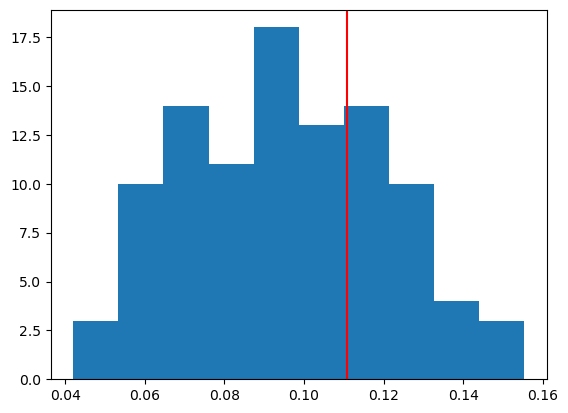

In [ ]:
fig, ax = plt.subplots()
ax.hist(rv_distr)
ax.axvline(rv_est, color='red')
plt.show()